In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline 

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Completed")

Completed


In [7]:
poverty_df = pd.read_csv("../data/poverty.csv")
inflation_df = pd.read_csv("../data/inflation.csv")

print(f"Inflation data loaded: {inflation_df.shape}")
print(f"Poverty data loaded: {poverty_df.shape}")

Inflation data loaded: (387, 66)
Poverty data loaded: (185, 102)


In [8]:
south_africa_inflation = inflation_df[
    (inflation_df["REF_AREA"] == "ZAF") & 
    (inflation_df["OBS_STATUS_LABEL"] == "Normal value")
]

south_africa_poverty = poverty_df[
    poverty_df["REF_AREA"] == "ZAF"
]

In [9]:
selected_years = ["1993", "2000", "2005", "2008", "2010", "2014", "2022"]
years_array = np.array([1993, 2000, 2005, 2008, 2010, 2014, 2022])

inflation_values = south_africa_inflation[selected_years].iloc[0].astype(float).to_numpy()
inflation_array = np.array(inflation_values)

poverty_values = south_africa_poverty[selected_years].iloc[0].astype(float).to_numpy()
poverty_array = np.array(poverty_values)

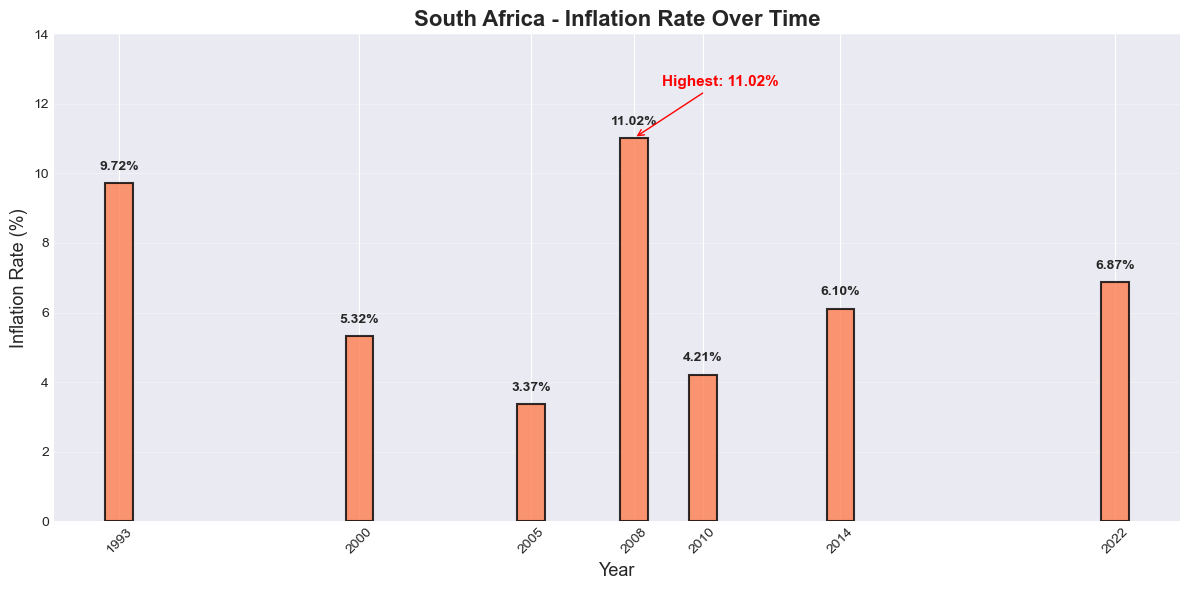

In [10]:
plt.figure(figsize=(12, 6))

bars = plt.bar(years_array, inflation_array, color='coral', alpha=0.8, edgecolor='black', linewidth=1.5)

for bar in bars: 
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.3,
    f'{height:.2f}%' , ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('South Africa - Inflation Rate Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=13)
plt.ylabel('Inflation Rate (%)', fontsize=13)
plt.xticks(years_array, rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 14)

max_idx = np.argmax(inflation_array)
plt.annotate(f'Highest: {inflation_array[max_idx]:.2f}%',
             xy=(years_array[max_idx], inflation_array[max_idx]),
             xytext=(years_array[max_idx] + 0.8, inflation_array[max_idx] + 1.5),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('inflation_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

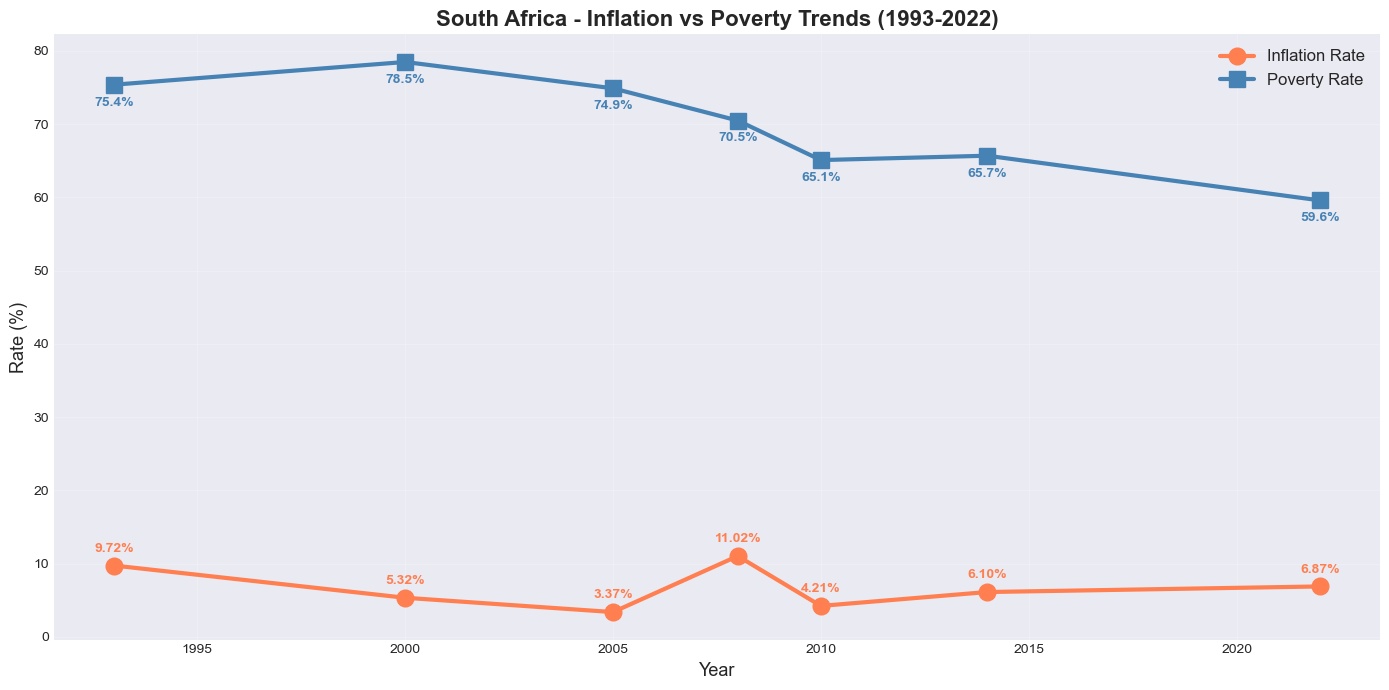

In [12]:
import matplotlib.pyplot as plt
import numpy as np

years_array = np.array([1993, 2000, 2005, 2008, 2010, 2014, 2022])
inflation_array = np.array([9.720, 5.322, 3.367, 11.020, 4.211, 6.104, 6.869])
poverty_array = np.array([75.4, 78.5, 74.9, 70.5, 65.1, 65.7, 59.6])

fig, ax = plt.subplots(figsize=(14, 7))

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Rate (%)', fontsize=13)

# Plot Inflation
line1 = ax.plot(years_array, inflation_array, color='coral', marker='o', 
                 linewidth=3, markersize=12, label='Inflation Rate')

# Plot Poverty
line2 = ax.plot(years_array, poverty_array, color='steelblue', marker='s', 
                 linewidth=3, markersize=12, label='Poverty Rate')

ax.grid(axis='both', alpha=0.2)


plt.title('South Africa - Inflation vs Poverty Trends (1993-2022)', 
          fontsize=16, fontweight='bold')

for i, (year, infl, pov) in enumerate(zip(years_array, inflation_array, poverty_array)):
    ax.annotate(f'{infl:.2f}%', (year, infl), textcoords="offset points", 
                 xytext=(0, 10), ha='center', fontsize=10, color='coral', fontweight='bold')
    ax.annotate(f'{pov:.1f}%', (year, pov), textcoords="offset points", 
                 xytext=(0, -15), ha='center', fontsize=10, color='steelblue', fontweight='bold')

ax.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.savefig('inflation_poverty_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

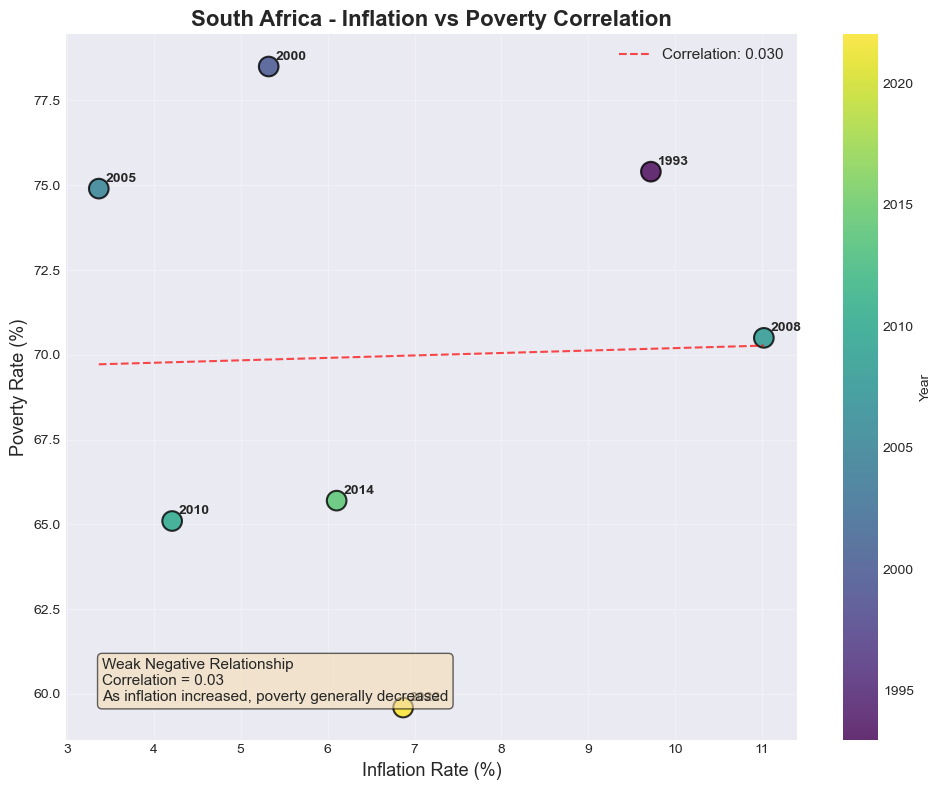

In [25]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(inflation_array, poverty_array, 
                      c=years_array, cmap='viridis', s=200, alpha=0.8, 
                      edgecolors='black', linewidth=1.5)

for i, year in enumerate(years_array):
    plt.annotate(str(year), 
                 (inflation_array[i], poverty_array[i]),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=10, fontweight='bold')

z = np.polyfit(inflation_array, poverty_array, 1)
p = np.poly1d(z)

x_trend = np.linspace(min(inflation_array), max(inflation_array), 100)
corr_value = np.corrcoef(inflation_array, poverty_array)[0, 1]

plt.plot(x_trend, p(x_trend), "r--", alpha=0.7, 
         label=f'Correlation: {corr_value:.3f}')

plt.title('South Africa - Inflation vs Poverty Correlation', 
          fontsize=16, fontweight='bold')
plt.xlabel('Inflation Rate (%)', fontsize=13)
plt.ylabel('Poverty Rate (%)', fontsize=13)
plt.colorbar(scatter, label='Year')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

insights_text = (f'Weak Negative Relationship\n'
                 f'Correlation = {corr_value:.2f}\n'
                 f'As inflation increased, poverty generally decreased')
plt.text(0.05, 0.05, insights_text, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.savefig('inflation_poverty_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

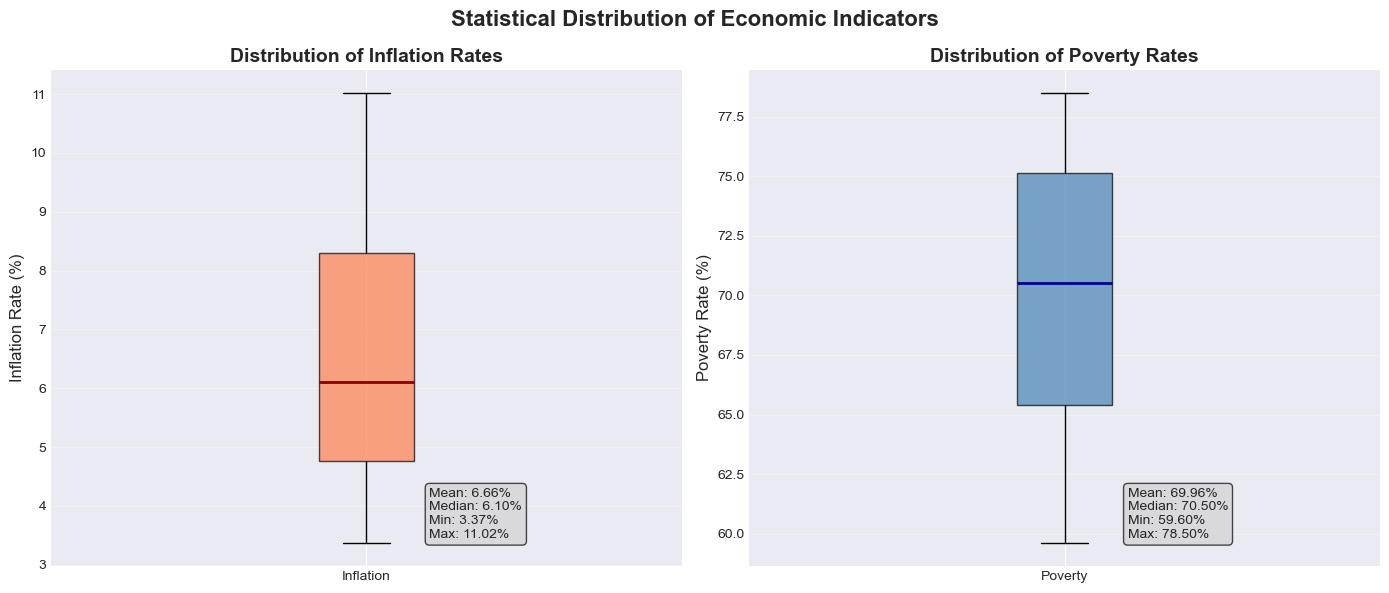

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.boxplot(inflation_array, vert=True, patch_artist=True,
            boxprops=dict(facecolor='coral', alpha=0.7),
            medianprops=dict(color='darkred', linewidth=2))
ax1.set_title('Distribution of Inflation Rates', fontsize=14, fontweight='bold')
ax1.set_ylabel('Inflation Rate (%)', fontsize=12)
ax1.set_xticklabels(['Inflation'])
ax1.grid(axis='y', alpha=0.3)

stats_text = (f'Mean: {np.mean(inflation_array):.2f}%\n'
              f'Median: {np.median(inflation_array):.2f}%\n'
              f'Min: {np.min(inflation_array):.2f}%\n'
              f'Max: {np.max(inflation_array):.2f}%')
ax1.text(0.6, 0.05, stats_text, transform=ax1.transAxes,
         fontsize=10, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))

ax2.boxplot(poverty_array, vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7),
            medianprops=dict(color='darkblue', linewidth=2))
ax2.set_title('Distribution of Poverty Rates', fontsize=14, fontweight='bold')
ax2.set_ylabel('Poverty Rate (%)', fontsize=12)
ax2.set_xticklabels(['Poverty'])
ax2.grid(axis='y', alpha=0.3)

stats_text2 = (f'Mean: {np.mean(poverty_array):.2f}%\n'
               f'Median: {np.median(poverty_array):.2f}%\n'
               f'Min: {np.min(poverty_array):.2f}%\n'
               f'Max: {np.max(poverty_array):.2f}%')
ax2.text(0.6, 0.05, stats_text2, transform=ax2.transAxes,
         fontsize=10, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))

plt.suptitle('Statistical Distribution of Economic Indicators', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('box_plots_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

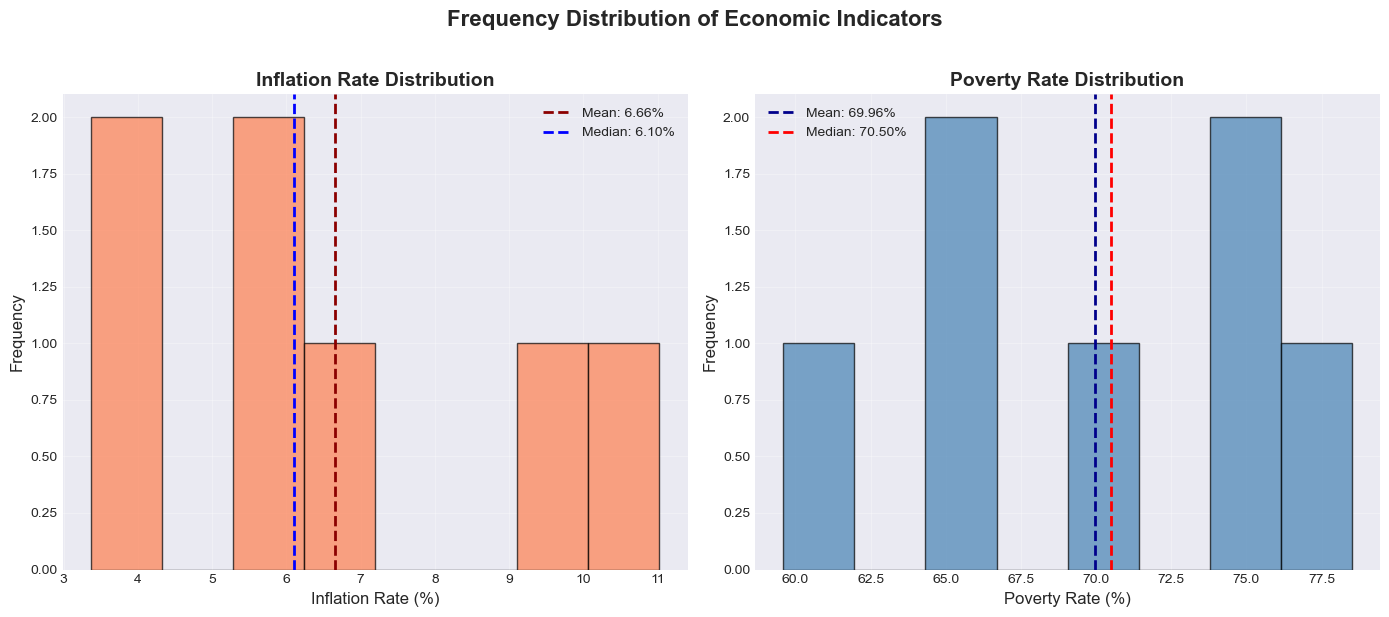

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


ax1.hist(inflation_array, bins=8, edgecolor='black', color='coral', alpha=0.7)
ax1.axvline(np.mean(inflation_array), color='darkred', linestyle='--',
            linewidth=2, label=f'Mean: {np.mean(inflation_array):.2f}%')
ax1.axvline(np.median(inflation_array), color='blue', linestyle='--',
            linewidth=2, label=f'Median: {np.median(inflation_array):.2f}%')
ax1.set_title('Inflation Rate Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Inflation Rate (%)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)


ax2.hist(poverty_array, bins=8, edgecolor='black', color='steelblue', alpha=0.7)
ax2.axvline(np.mean(poverty_array), color='darkblue', linestyle='--',
            linewidth=2, label=f'Mean: {np.mean(poverty_array):.2f}%')
ax2.axvline(np.median(poverty_array), color='red', linestyle='--',
            linewidth=2, label=f'Median: {np.median(poverty_array):.2f}%')
ax2.set_title('Poverty Rate Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Poverty Rate (%)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)


plt.suptitle('Frequency Distribution of Economic Indicators',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('histogram_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

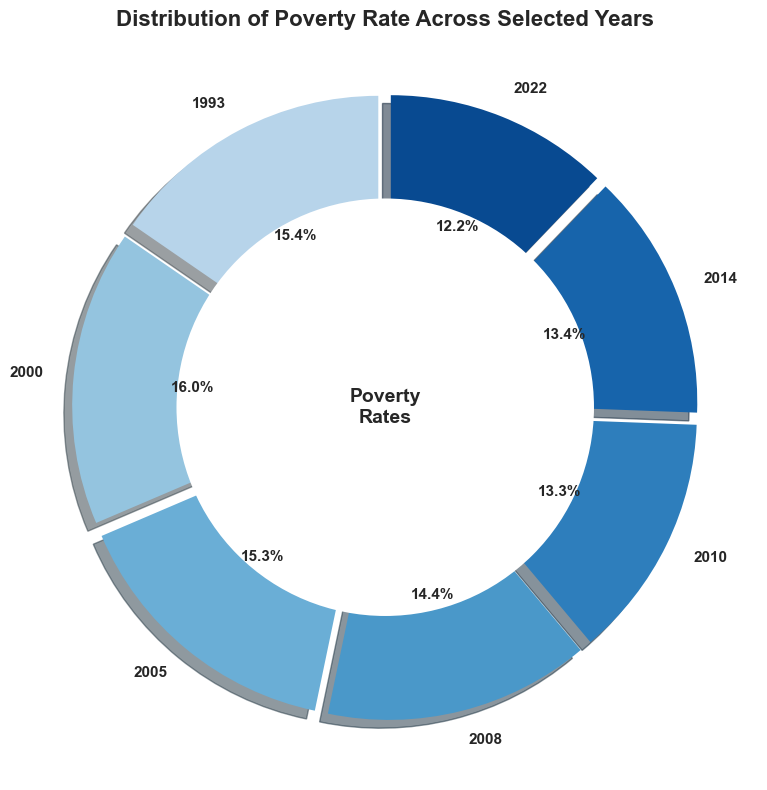

In [28]:
plt.figure(figsize=(10, 8))

colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(years_array)))
explode = [0.05] * len(years_array)  # Slight explode for all slices

plt.pie(poverty_array, labels=years_array, autopct='%1.1f%%', 
        colors=colors, explode=explode, shadow=True, startangle=90,
        textprops={'fontsize': 11, 'fontweight': 'bold'})

plt.title('Distribution of Poverty Rate Across Selected Years', 
          fontsize=16, fontweight='bold')

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.text(0, 0, 'Poverty\nRates', ha='center', va='center', 
         fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('poverty_pie_chart.png', dpi=300, bbox_inches='tight')
plt.show()

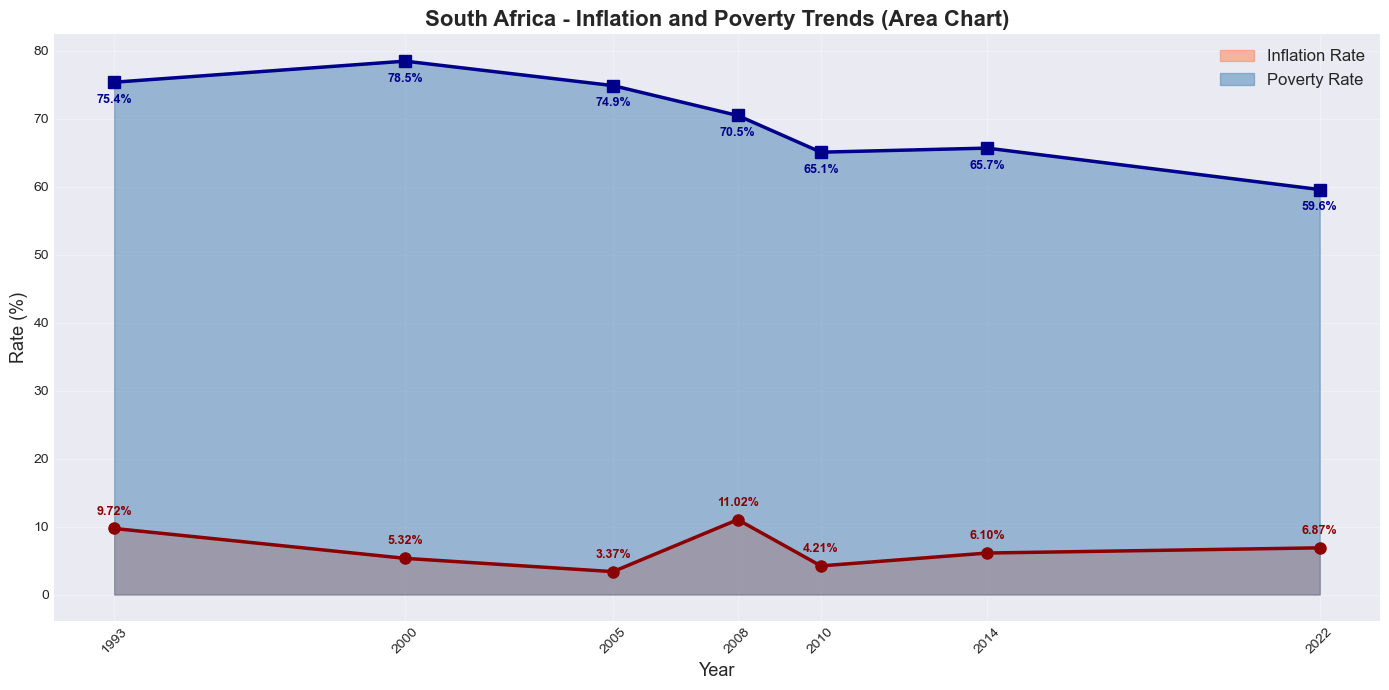

In [29]:
plt.figure(figsize=(14, 7))

plt.fill_between(years_array, 0, inflation_array, alpha=0.5, color='coral', label='Inflation Rate')
plt.fill_between(years_array, 0, poverty_array, alpha=0.5, color='steelblue', label='Poverty Rate')

plt.plot(years_array, inflation_array, 'o-', color='darkred', linewidth=2.5, markersize=8)
plt.plot(years_array, poverty_array, 's-', color='darkblue', linewidth=2.5, markersize=8)

plt.title('South Africa - Inflation and Poverty Trends (Area Chart)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=13)
plt.ylabel('Rate (%)', fontsize=13)
plt.xticks(years_array, rotation=45)
plt.legend(fontsize=12, loc='upper right')
plt.grid(alpha=0.3)

for i, year in enumerate(years_array):
    plt.annotate(f'{inflation_array[i]:.2f}%',
                 (year, inflation_array[i]),
                 textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=9, color='darkred', fontweight='bold')
    
    plt.annotate(f'{poverty_array[i]:.1f}%',
                 (year, poverty_array[i]),
                 textcoords="offset points", xytext=(0, -15),
                 ha='center', fontsize=9, color='darkblue', fontweight='bold')

plt.tight_layout()
plt.savefig('area_chart_trends.png', dpi=300, bbox_inches='tight')
plt.show()

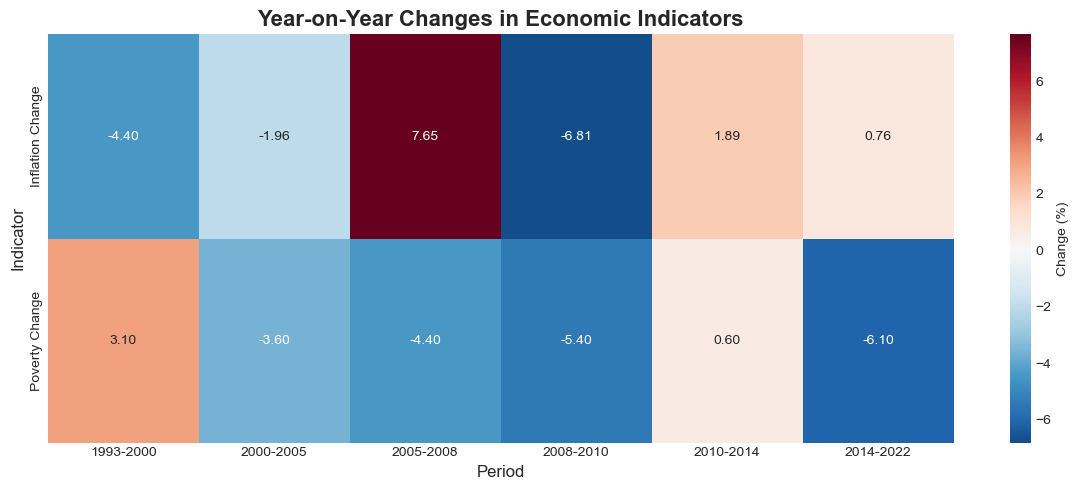

In [30]:
inflation_changes = np.diff(inflation_array).reshape(1, -1)
poverty_changes = np.diff(poverty_array).reshape(1, -1)

change_matrix = np.vstack([inflation_changes, poverty_changes])

change_years = [f"{years_array[i]}-{years_array[i+1]}" for i in range(len(years_array) - 1)]
row_labels = ['Inflation Change', 'Poverty Change']

plt.figure(figsize=(12, 5))

sns.heatmap(change_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=change_years, yticklabels=row_labels, 
            cbar_kws={'label': 'Change (%)'})

plt.title('Year-on-Year Changes in Economic Indicators', fontsize=16, fontweight='bold')
plt.xlabel('Period', fontsize=12)
plt.ylabel('Indicator', fontsize=12)

plt.tight_layout()
plt.savefig('change_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

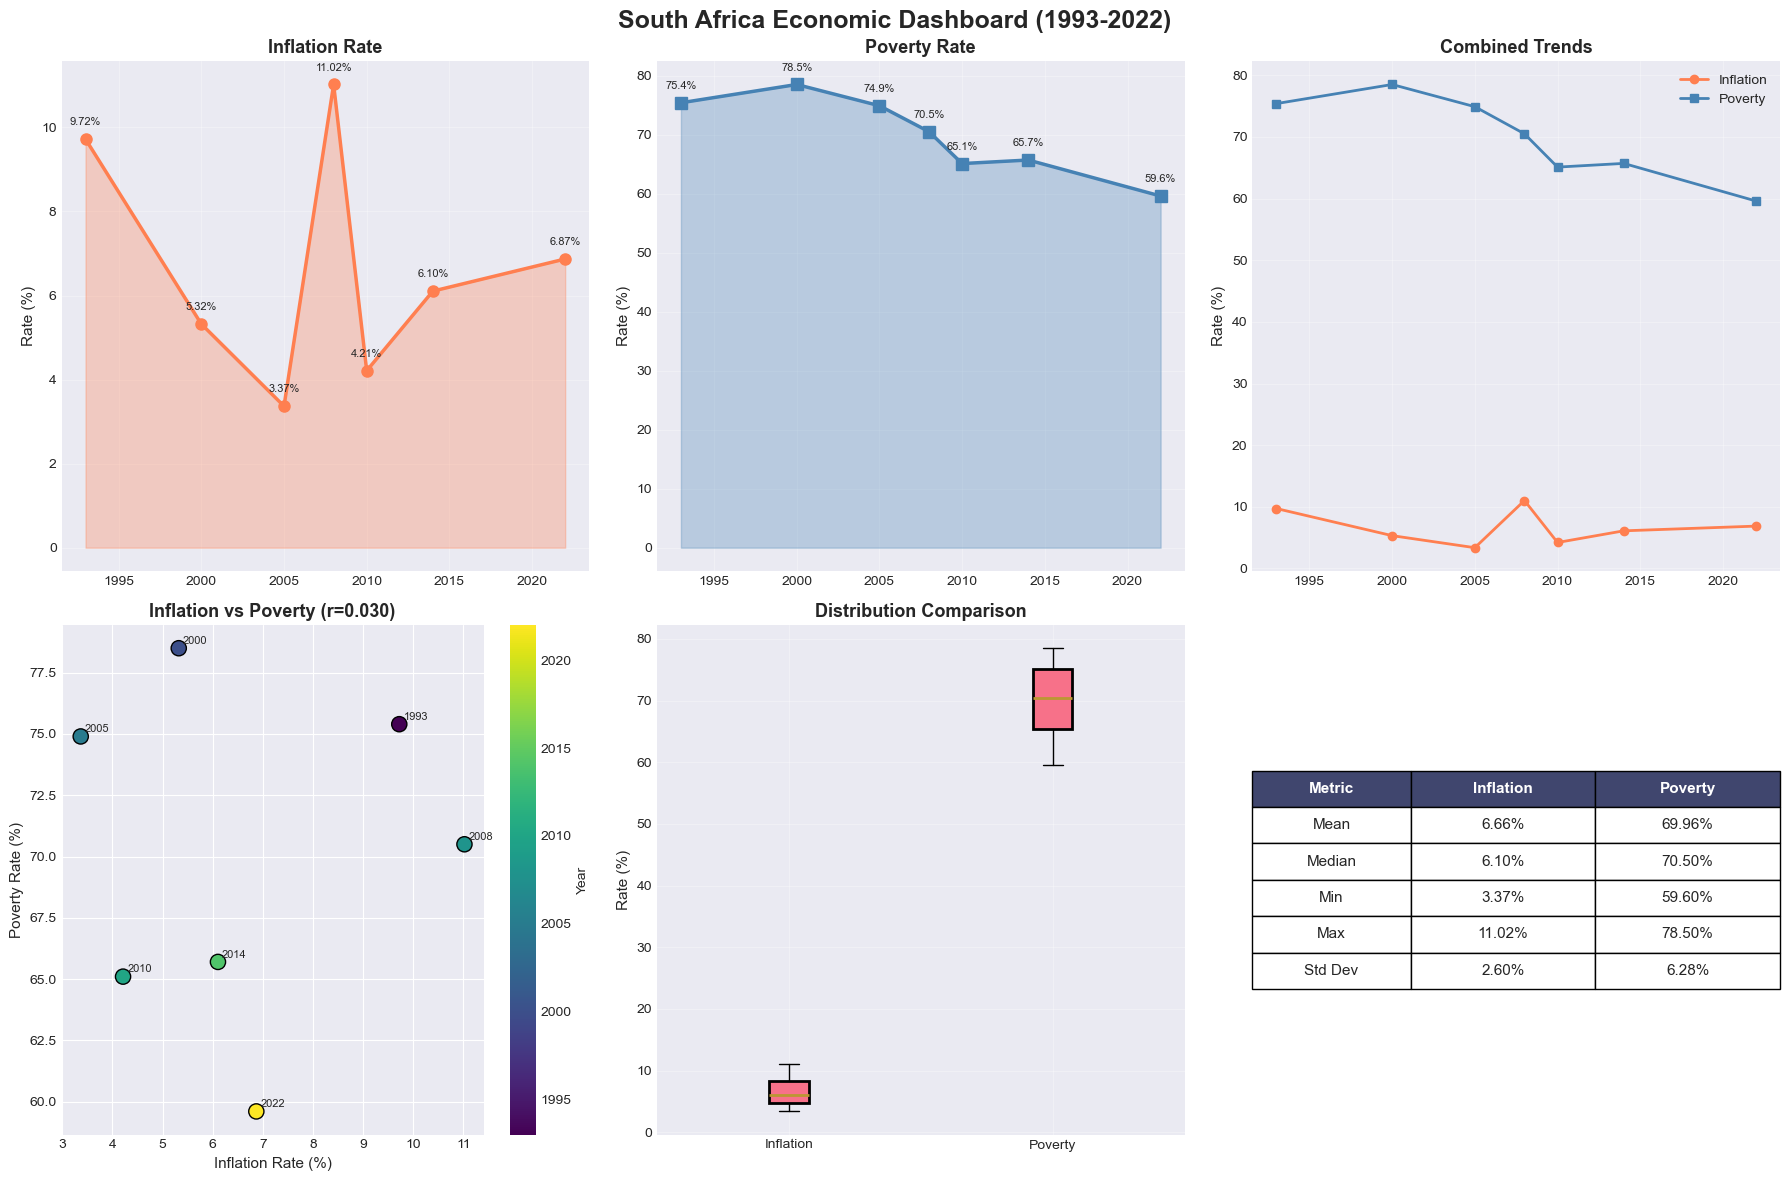

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('South Africa Economic Dashboard (1993-2022)', 
             fontsize=18, fontweight='bold')

# 1. Inflation Trend
ax = axes[0, 0]
ax.plot(years_array, inflation_array, 'o-', color='coral', linewidth=2.5, markersize=8)
ax.fill_between(years_array, inflation_array, alpha=0.3, color='coral')
ax.set_title('Inflation Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('Rate (%)', fontsize=11)
ax.grid(alpha=0.3)
for i, v in enumerate(inflation_array):
    ax.annotate(f'{v:.2f}%', (years_array[i], v), textcoords="offset points", 
                xytext=(0, 10), ha='center', fontsize=8)

# 2. Poverty Trend
ax = axes[0, 1]
ax.plot(years_array, poverty_array, 's-', color='steelblue', linewidth=2.5, markersize=8)
ax.fill_between(years_array, poverty_array, alpha=0.3, color='steelblue')
ax.set_title('Poverty Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('Rate (%)', fontsize=11)
ax.grid(alpha=0.3)
for i, v in enumerate(poverty_array):
    ax.annotate(f'{v:.1f}%', (years_array[i], v), textcoords="offset points", 
                xytext=(0, 10), ha='center', fontsize=8)

# 3. Combined Trend
ax = axes[0, 2]
ax.plot(years_array, inflation_array, 'o-', color='coral', linewidth=2, label='Inflation')
ax.plot(years_array, poverty_array, 's-', color='steelblue', linewidth=2, label='Poverty')
ax.set_title('Combined Trends', fontsize=13, fontweight='bold')
ax.set_ylabel('Rate (%)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 4. Correlation Scatter
ax = axes[1, 0]
scatter = ax.scatter(inflation_array, poverty_array, c=years_array, 
                     cmap='viridis', s=120, edgecolors='black')
for i, year in enumerate(years_array):
    ax.annotate(str(year), (inflation_array[i], poverty_array[i]),
                xytext=(3, 3), textcoords='offset points', fontsize=8)
ax.set_title(f'Inflation vs Poverty (r={np.corrcoef(inflation_array, poverty_array)[0,1]:.3f})', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Inflation Rate (%)', fontsize=11)
ax.set_ylabel('Poverty Rate (%)', fontsize=11)
plt.colorbar(scatter, ax=ax, label='Year')

# 5. Box Plot Comparison
bp_data = [inflation_array, poverty_array]
bp = ax = axes[1, 1]
bp.boxplot(bp_data, tick_labels=['Inflation', 'Poverty'], patch_artist=True,
           boxprops=dict(linewidth=2), medianprops=dict(linewidth=2))
bp.set_title('Distribution Comparison', fontsize=13, fontweight='bold')
bp.set_ylabel('Rate (%)', fontsize=11)
bp.grid(alpha=0.3)

# 6. Summary Statistics Table
ax = axes[1, 2]
ax.axis('tight')
ax.axis('off')
stats_data = [
    ['Metric', 'Inflation', 'Poverty'],
    ['Mean', f'{np.mean(inflation_array):.2f}%', f'{np.mean(poverty_array):.2f}%'],
    ['Median', f'{np.median(inflation_array):.2f}%', f'{np.median(poverty_array):.2f}%'],
    ['Min', f'{np.min(inflation_array):.2f}%', f'{np.min(poverty_array):.2f}%'],
    ['Max', f'{np.max(inflation_array):.2f}%', f'{np.max(poverty_array):.2f}%'],
    ['Std Dev', f'{np.std(inflation_array):.2f}%', f'{np.std(poverty_array):.2f}%']
]
table = ax.table(cellText=stats_data, loc='center', cellLoc='center', 
                 colWidths=[0.3, 0.35, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)
for i in range(3):
    table[0, i].set_facecolor('#40466e')
    table[0, i].set_text_props(color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('economic_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()